# ADL Lab 3.1

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Task 3.1.1 - MLP for MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_train = datasets.MNIST(root='data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=transform)

mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [50000, 10000])

train_loader = DataLoader(mnist_train, batch_size=512, shuffle=True)
val_loader = DataLoader(mnist_val, batch_size=512, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=512, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.82MB/s]


Min: -1.0
Max: 1.0
Mean: -0.7119048237800598
Input shape: torch.Size([1, 28, 28])
Input tensor: tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.000

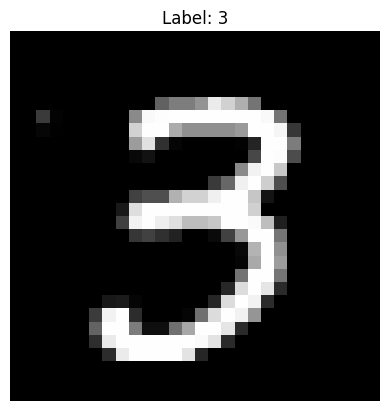

In [3]:
# (a) Sample inspection
img, label = mnist_train[0]

print("Min:", img.min().item())
print("Max:", img.max().item())
print("Mean:", img.mean().item())

print("Input shape:", img.shape)
print("Input tensor:", img)
print("Output label:", label)

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [4]:
class MLP(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 10)
        )
    def forward(self,x):
        return self.net(x)

In [5]:
def train_eval(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(20):
        model.train()
        t_loss = 0
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out,y)
            loss.backward()
            opt.step()
            t_loss += loss.item()

        t_loss /= len(train_loader)
        train_losses.append(t_loss)

        model.eval()
        v_loss = 0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                v_loss += loss_fn(model(x),y).item()

        v_loss /= len(val_loader)
        val_losses.append(v_loss)

    # test accuracy
    correct,total=0,0
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            total += y.size(0)
            correct += (pred==y).sum().item()

    acc = 100*correct/total
    params = sum(p.numel() for p in model.parameters())

    return train_losses, val_losses, acc, params

Training hidden size 16
Training hidden size 32
Training hidden size 64


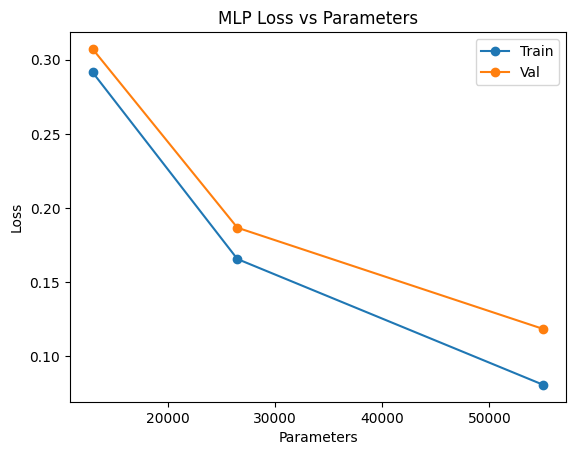

In [6]:
hidden_sizes = [16,32,64]
results = {}

for h in hidden_sizes:
    print(f"Training hidden size {h}")
    model = MLP(h)
    tr,vl,acc,params = train_eval(model)
    results[h] = {"train":tr[-1],"val":vl[-1],"acc":acc,"params":params}

# plot
params = [results[h]["params"] for h in hidden_sizes]
train_loss = [results[h]["train"] for h in hidden_sizes]
val_loss = [results[h]["val"] for h in hidden_sizes]

plt.plot(params, train_loss, marker='o', label="Train")
plt.plot(params, val_loss, marker='o', label="Val")
plt.xlabel("Parameters")
plt.ylabel("Loss")
plt.title("MLP Loss vs Parameters")
plt.legend()
plt.show()

In [7]:
print("\nFinal Results (Hidden Size | Params | Train Loss | Val Loss | Test Acc)")
print("-"*75)

for h in hidden_sizes:
    print(f"{h:>10} | "
          f"{results[h]['params']:>10} | "
          f"{results[h]['train']:.4f} | "
          f"{results[h]['val']:.4f} | "
          f"{results[h]['acc']:.2f}%")


Final Results (Hidden Size | Params | Train Loss | Val Loss | Test Acc)
---------------------------------------------------------------------------
        16 |      13002 | 0.2915 | 0.3073 | 91.49%
        32 |      26506 | 0.1656 | 0.1867 | 94.76%
        64 |      55050 | 0.0806 | 0.1183 | 96.51%


## Task 3.1.2 - CNN

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        x = self.conv(x)
        x = self.gap(x)
        x = torch.flatten(x,1)
        return self.fc(x)

In [9]:
def count_params(model):
    total=0
    for name,p in model.named_parameters():
        if p.requires_grad:
            print(name, p.numel())
            total+=p.numel()
    print("Total:", total)
    return total

In [10]:
model = CNN()
count_params(model)

# train + eval (same style)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

train_losses, val_losses = [], []

for epoch in range(20):
    model.train()
    t=0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = loss_fn(model(x),y)
        loss.backward()
        opt.step()
        t+=loss.item()
    t/=len(train_loader)
    train_losses.append(t)

    model.eval()
    v=0
    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            v+=loss_fn(model(x),y).item()
    v/=len(val_loader)
    val_losses.append(v)

    print(epoch, t, v)

# test accuracy
correct,total=0,0
with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        total+=y.size(0)
        correct+=(pred==y).sum().item()

print("Test Acc:",100*correct/total)

conv.0.weight 288
conv.0.bias 32
conv.3.weight 18432
conv.3.bias 64
fc.0.weight 4096
fc.0.bias 64
fc.2.weight 640
fc.2.bias 10
Total: 23626
0 2.0473606756755283 1.6727316558361054
1 1.5175540094472924 1.3745152175426483
2 1.2980682107867028 1.1871456325054168
3 1.108401698725564 1.0113873213529587
4 0.9637704047621513 0.8910829067230225
5 0.8510462167311688 0.792335131764412
6 0.7562793906854124 0.7013827353715897
7 0.68508872937183 0.6557989597320557
8 0.6259941701986351 0.6033027619123459
9 0.5817359874443132 0.5439159199595451
10 0.5449742185217994 0.515582486987114
11 0.5159282626546159 0.48412192463874815
12 0.4897506507683773 0.46454630345106124
13 0.468841656738398 0.4399434939026833
14 0.4502241143158504 0.42945859730243685
15 0.42815025606933904 0.4262849986553192
16 0.41170580076928043 0.3918983846902847
17 0.39320624756569766 0.3732724368572235
18 0.37832580202696275 0.36004127413034437
19 0.36518787486212595 0.34673715233802793
Test Acc: 89.85



Final Loss Comparison
--------------------------------------------------
Final Training Loss   : 0.3652
Final Validation Loss : 0.3467

Model Behavior Analysis
--------------------------------------------------
Training and Validation loss are similar → Good Generalization


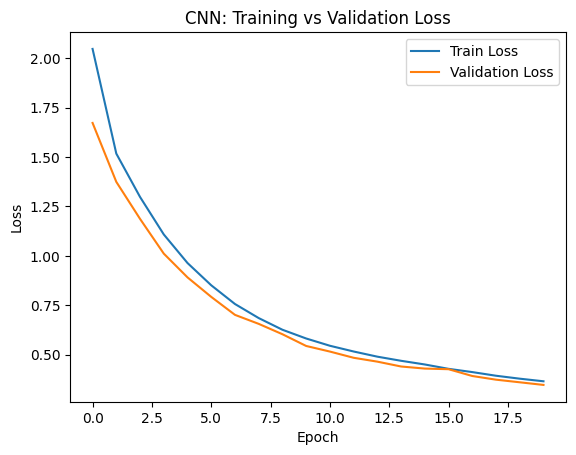


Total Trainable Parameters: 23626

Sample Predictions (first batch):
Predictions: [7 2 1 0 4 1 4 8 2 9]
Ground Truth: [7 2 1 0 4 1 4 9 5 9]


In [11]:
# ===================== Analysis & Debug Cell =====================

# 1. Final Loss Comparison
print("\nFinal Loss Comparison")
print("-"*50)
print(f"Final Training Loss   : {train_losses[-1]:.4f}")
print(f"Final Validation Loss : {val_losses[-1]:.4f}")

# 2. Overfitting / Generalization Check
print("\nModel Behavior Analysis")
print("-"*50)
if val_losses[-1] > train_losses[-1]:
    print("Validation loss > Training loss → Possible Overfitting")
else:
    print("Training and Validation loss are similar → Good Generalization")

# 3. Loss Plot
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN: Training vs Validation Loss")
plt.legend()
plt.show()

# 4. Parameter Count (clean summary again)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTotal Trainable Parameters:", total_params)

# 5.Quick sanity check on predictions
print("\nSample Predictions (first batch):")
model.eval()
with torch.no_grad():
    x, y = next(iter(test_loader))
    x, y = x.to(device), y.to(device)
    preds = model(x).argmax(1)

print("Predictions:", preds[:10].cpu().numpy())
print("Ground Truth:", y[:10].cpu().numpy())

## Task 3.1.3 - Autoencoder

In [14]:
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1,32,3,2,1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,2,1),
            nn.ReLU()
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64,32,3,2,1,1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,3,2,1,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.dec(self.enc(x))

In [15]:
model = AE()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(20):
    model.train()
    t=0
    for x,_ in train_loader:
        x=x.to(device)
        opt.zero_grad()
        loss = loss_fn(model(x),x)
        loss.backward()
        opt.step()
        t+=loss.item()
    t/=len(train_loader)
    print("Epoch",epoch,t)

Epoch 0 1.0093270077997325
Epoch 1 0.9254180302425307
Epoch 2 0.9253830015659332
Epoch 3 0.9253582559069808
Epoch 4 0.9253551941745135
Epoch 5 0.9253483937711132
Epoch 6 0.9253427732963951
Epoch 7 0.9253460825706015
Epoch 8 0.9253465040605895
Epoch 9 0.9253458459766544
Epoch 10 0.9253479345720641
Epoch 11 0.9253436521608003
Epoch 12 0.9253387955986724
Epoch 13 0.9253446581412335
Epoch 14 0.9253402376661495
Epoch 15 0.9163989497690784
Epoch 16 0.8584599841614159
Epoch 17 0.8368525134057415
Epoch 18 0.8352099492841837
Epoch 19 0.8344514217911935


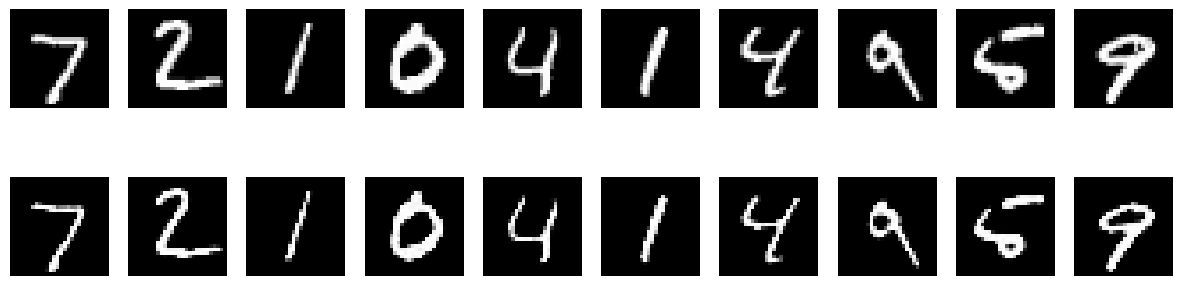

In [16]:
# visualization (10 images)
imgs,_ = next(iter(test_loader))
imgs = imgs.to(device)

with torch.no_grad():
    recon = model(imgs)

imgs, recon = imgs.cpu(), recon.cpu()

fig,ax = plt.subplots(2,10,figsize=(15,4))
for i in range(10):
    ax[0,i].imshow(imgs[i].squeeze(), cmap='gray')
    ax[0,i].axis('off')
    ax[1,i].imshow(recon[i].squeeze(), cmap='gray')
    ax[1,i].axis('off')

plt.show()

# Thank you